In [1]:
import cv2
import time
import numpy as np
from IPython.display import Video
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
import os
from glob import glob
from PIL import Image
from tqdm import tqdm

img_root = "C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\images"
label_root = "C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\labels"

In [2]:
classes_rgb = pd.read_csv(r"C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\classes_rgb_values.csv")
print(classes_rgb)

    index semantic_class     rgb_values  relative_percentile_frequency
0       0   Traffic Sign    [220,220,0]                           0.05
1       1       Building     [70,70,70]                          14.08
2       2          Fence  [190,153,153]                           0.28
3       3          Other  [250,170,160]                           0.29
4       4     Pedestrian    [220,20,60]                           1.02
5       5           Pole  [153,153,153]                           0.74
6       6      Road Line   [157,234,50]                           1.86
7       7           Road   [128,64,128]                          33.80
8       8       Sidewalk   [244,35,232]                           5.85
9       9     Vegetation   [107,142,35]                           4.78
10     10            Car      [0,0,142]                           3.63
11     11           Wall  [102,102,156]                           0.82
12     12      Unlabeled        [0,0,0]                          32.81


In [3]:
video_info = pd.read_csv(r"C:\\Facultate\\Facultate\\Anul 3\\Semestrul 1\\KBS\\Proiect\\archive\\video_info.csv")
print(video_info)

    Index  duration_seconds weather      driving_scenario  n_images
0       0              30.4   Sunny               Driving       305
1       1              34.1   Sunny  Driving + Traffic am       342
2       2              36.2   Sunny               Driving       363
3       3              35.0   Sunny  Driving + Traffic am       350
4       4              33.4   Sunny               Driving       335
5       5              38.9   Sunny  Driving + Traffic am       390
6       6              39.6   Sunny         Traffic Light       397
7       7              44.2   Sunny         Traffic Light       443
8       8              39.3   Sunny               Driving       393
9       9              36.3   Sunny               Driving       364
10     10              43.7   Sunny               Driving       438
11     11              34.5   Sunny               Driving       346
12     12              37.9   Sunny  Driving + Traffic am       380
13     13              32.5   Sunny             

In [4]:
sunny_videos = video_info[video_info["weather"] == "Sunny"]["Index"].tolist()
rainy_videos = video_info[video_info["weather"] == "Rainy"]["Index"].tolist()
cloudy_videos = video_info[video_info["weather"] == "Cloudy"]["Index"].tolist()

print("Sunny videos:", sunny_videos)
print("Rainy videos:", rainy_videos)
print("Cloudy videos:", cloudy_videos)

Sunny videos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Rainy videos: [14, 16, 17, 18, 20, 21, 22, 23, 26]
Cloudy videos: [15, 19, 24, 25, 27]


In [5]:
sunny_frames  = video_info[video_info["weather"] == "Sunny"]["n_images"].sum()
rainy_frames  = video_info[video_info["weather"] == "Rainy"]["n_images"].sum()
cloudy_frames = video_info[video_info["weather"] == "Cloudy"]["n_images"].sum()

print("Sunny frames :", sunny_frames)
print("Rainy frames :", rainy_frames)
print("Cloudy frames:", cloudy_frames)

Sunny frames : 5171
Rainy frames : 3443
Cloudy frames: 2153


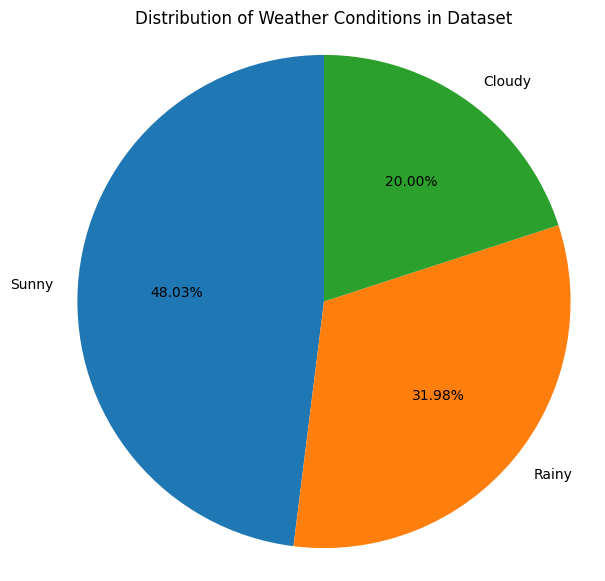

In [6]:
plt.figure(figsize=(7,7))
plt.pie([sunny_frames, rainy_frames, cloudy_frames], labels=["Sunny", "Rainy", "Cloudy"], autopct='%1.2f%%', startangle=90)
plt.title("Distribution of Weather Conditions in Dataset")
plt.axis("equal")  # makes the pie a circle
plt.show()

In [7]:
video_groups = video_info.groupby(["weather", "driving_scenario"])["Index"].apply(list)

print("Video groups (weather, scenario):")
for key, vids in video_groups.items():
    print(f"{key}: {vids}")

Video groups (weather, scenario):
('Cloudy', 'Driving'): [15, 19, 25, 27]
('Cloudy', 'Driving + Traffic am'): [24]
('Rainy', 'Driving'): [17, 20, 23]
('Rainy', 'Driving + Traffic am'): [14, 16, 26]
('Rainy', 'Traffic Light'): [18, 21, 22]
('Sunny', 'Driving'): [0, 2, 4, 8, 9, 10, 11, 13]
('Sunny', 'Driving + Traffic am'): [1, 3, 5, 12]
('Sunny', 'Traffic Light'): [6, 7]


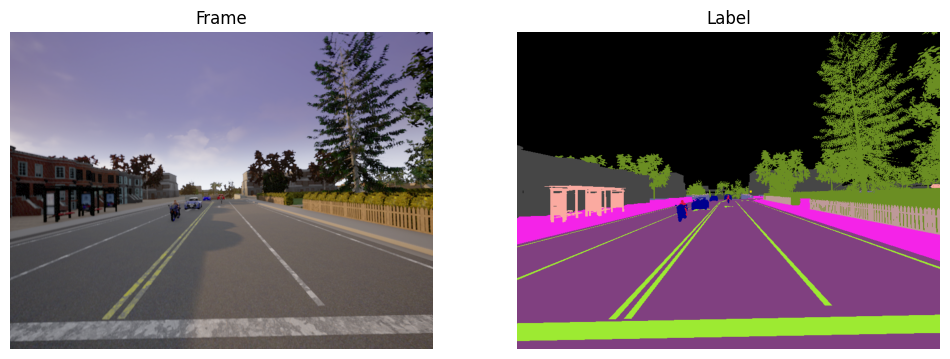

In [8]:
# Example of a photo and a label
img_path = img_root + "/Video_000/v000_0000.png"
label_path = label_root + "/Video_000/v000_0000.png"

img = cv2.imread(img_path)
label = cv2.imread(label_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Frame")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(label)
plt.title("Label")
plt.axis("off")

plt.show()

In [9]:
print("Label shape:", label.shape)
print("Unique colors:\n", np.unique(label.reshape(-1, 3), axis=0))

Label shape: (600, 800, 3)
Unique colors:
 [[  0   0   0]
 [  0   0 142]
 [ 70  70  70]
 [102 102 156]
 [107 142  35]
 [128  64 128]
 [153 153 153]
 [157 234  50]
 [190 153 153]
 [220  20  60]
 [220 220   0]
 [244  35 232]
 [250 170 160]]


In [10]:
rgb_values = np.array(classes_rgb["rgb_values"].apply(eval).tolist())
print(rgb_values)

[[220 220   0]
 [ 70  70  70]
 [190 153 153]
 [250 170 160]
 [220  20  60]
 [153 153 153]
 [157 234  50]
 [128  64 128]
 [244  35 232]
 [107 142  35]
 [  0   0 142]
 [102 102 156]
 [  0   0   0]]


In [11]:
# Function - creating the classId matrix
def classid(label_rgb, rgb_values):
    h, w, _ = label_rgb.shape
    label_flat = label_rgb.reshape(-1, 3)
    
    class_ids = np.full((label_flat.shape[0],), fill_value=12, dtype=np.int64)

    for idx, rgb in enumerate(rgb_values):
        mask = np.all(label_flat == rgb, axis=1)
        class_ids[mask] = idx

    return class_ids.reshape(h, w)

Class mask shape: (600, 800)
Unique class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


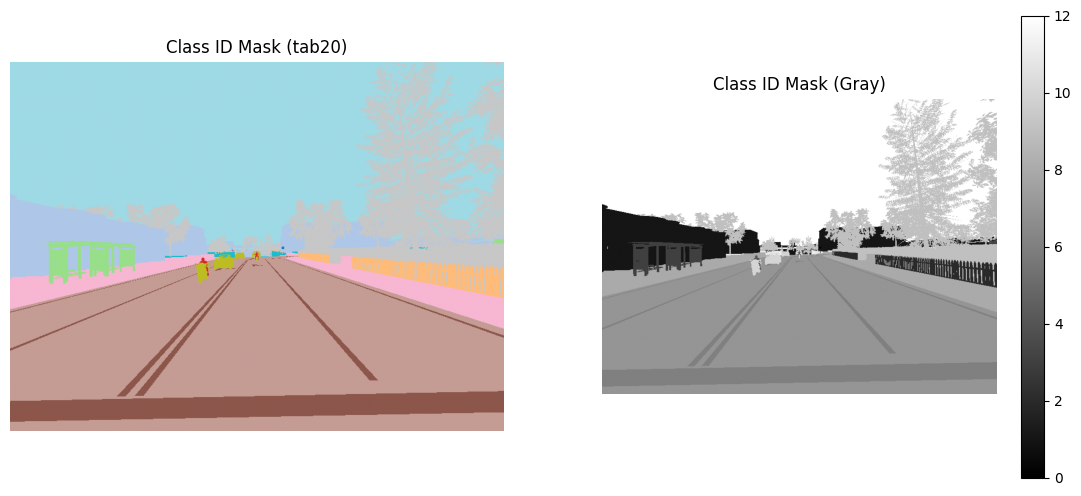

In [12]:
class_id_mask = classid(label, rgb_values)

print("Class mask shape:", class_id_mask.shape)
print("Unique class IDs:", np.unique(class_id_mask))

plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plt.imshow(class_id_mask, cmap="tab20")
plt.title("Class ID Mask (tab20)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(class_id_mask, cmap="gray")
plt.colorbar()
plt.title("Class ID Mask (Gray)")
plt.axis("off")

plt.show()

In [13]:
video_names = sorted(os.listdir(img_root))
video_frames = [] # list of (video, (image_path, label_path))

for vid in video_names:
    img_dir = os.path.join(img_root, vid)
    label_dir = os.path.join(label_root, vid)

    # list with all frame file names in this video
    frame_names = sorted(os.listdir(img_dir))

    frames = []

    for name in frame_names:
        img_path = os.path.join(img_dir, name)
        label_path = os.path.join(label_dir, name)

        if os.path.isfile(img_path) and os.path.isfile(label_path):
            frames.append((img_path, label_path))
    video_frames.append(frames)

for i, frames in enumerate(video_frames):
    print(f"Video {i} has {len(frames)} frames")

Video 0 has 305 frames
Video 1 has 342 frames
Video 2 has 363 frames
Video 3 has 350 frames
Video 4 has 335 frames
Video 5 has 390 frames
Video 6 has 397 frames
Video 7 has 443 frames
Video 8 has 393 frames
Video 9 has 364 frames
Video 10 has 438 frames
Video 11 has 346 frames
Video 12 has 380 frames
Video 13 has 325 frames
Video 14 has 357 frames
Video 15 has 384 frames
Video 16 has 350 frames
Video 17 has 360 frames
Video 18 has 374 frames
Video 19 has 431 frames
Video 20 has 366 frames
Video 21 has 448 frames
Video 22 has 351 frames
Video 23 has 451 frames
Video 24 has 443 frames
Video 25 has 438 frames
Video 26 has 386 frames
Video 27 has 457 frames


In [14]:
def display_frame(video, frame):
    img_path, label_path = video_frames[video][frame]
    
    # load image + label
    img = cv2.imread(img_path)
    label = cv2.imread(label_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)

    class_id_mask = classid(label, rgb_values)

    plt.figure(figsize=(14,6))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(label)
    plt.title("Label (RGB)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(class_id_mask, cmap="gray")
    plt.colorbar()
    plt.title("Class ID Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

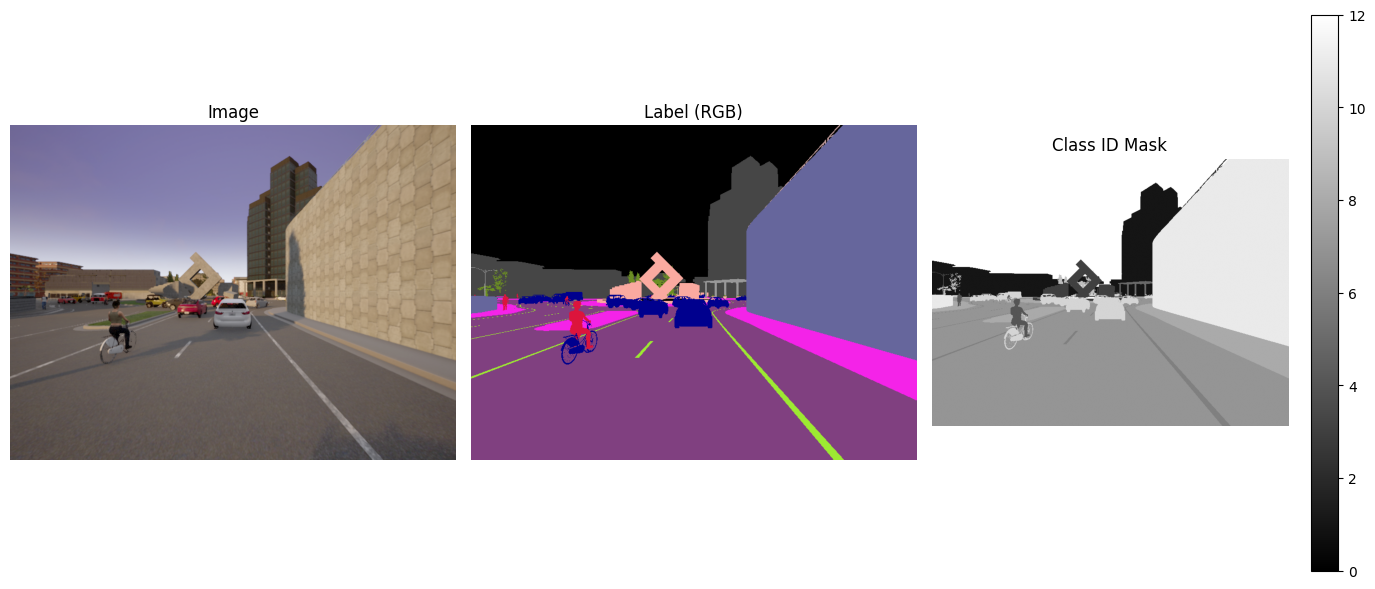

In [15]:
video = 4
frame = 100

display_frame(video, frame)

In [16]:
import random
random.seed(42)

train_videos = []
val_videos = []

for (weather, scenario), vids in video_groups.items():
    vids = vids.copy()
    random.shuffle(vids)
    
    n = len(vids)
    
    if n == 1:
        train_videos.append(vids[0])
    else:
        n_val = max(1, int(round(0.3 * n)))
        val_videos.extend(vids[:n_val])
        train_videos.extend(vids[n_val:])

print("Train videos:", len(train_videos), sorted(train_videos))
print("Val videos:", len(val_videos), sorted(val_videos))

Train videos: 20 [0, 2, 3, 5, 6, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 22, 23, 24, 26, 27]
Val videos: 8 [1, 4, 7, 8, 16, 20, 21, 25]


In [17]:
train_frames = []
val_frames = []

for vid in train_videos:
    frames = video_frames[vid]
    train_frames.extend(frames)

for vid in val_videos:
    frames = video_frames[vid]
    val_frames.extend(frames)
    
print("Selected videos for validation:")
print("Total training frames:", len(train_frames))
print("Total validating frames:", len(val_frames))

Selected videos for validation:
Total training frames: 7652
Total validating frames: 3115


In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

num_classes = len(rgb_values)
unknown_id = 12

In [20]:
class CarlaDataset:
    def __init__(self, frame_list, rgb_values, img_size=None):
        self.items = frame_list
        self.rgb_values = rgb_values
        self.img_size = img_size

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label_path = self.items[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label = cv2.imread(label_path)
        label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)

        if self.img_size is not None:
            w, h = self.img_size
            img = cv2.resize(img, (w, h), interpolation=cv2.INTER_LINEAR)
            label = cv2.resize(label, (w, h), interpolation=cv2.INTER_NEAREST)
            
        class_id_mask = classid(label, self.rgb_values).astype(np.int64)

        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  # CHW format

        # to torch tensors
        img_t = torch.from_numpy(img)               
        mask_t = torch.from_numpy(class_id_mask).long()

        return img_t, mask_t

In [21]:
img_size = (512, 384)
train_dataset = CarlaDataset(train_frames, rgb_values, img_size=img_size)
val_dataset = CarlaDataset(val_frames, rgb_values, img_size=img_size)

In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=13, base=32, depth=2):
        super().__init__()
        self.depth = depth

        enc_channels = [in_channels] + [base * (2**i) for i in range(depth)]
        self.enc = nn.ModuleList([DoubleConv(enc_channels[i], enc_channels[i+1]) for i in range(depth)])
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(enc_channels[-1], enc_channels[-1] * 2)

        dec_in = enc_channels[-1] * 2
        self.up = nn.ModuleList()
        self.dec = nn.ModuleList()
        for i in reversed(range(depth)):
            out_ch = enc_channels[i+1]
            self.up.append(nn.ConvTranspose2d(dec_in, out_ch, kernel_size=2, stride=2))
            self.dec.append(DoubleConv(out_ch + out_ch, out_ch))  # concat(up, skip)
            dec_in = out_ch

        self.out = nn.Conv2d(base, num_classes, kernel_size=1)

    def forward(self, x):
        skips = []

        for enc_block in self.enc:
            x = enc_block(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, dec_block in zip(self.up, self.dec):
            x = up(x)
            skip = skips.pop()
            x = torch.cat([x, skip], dim=1)
            x = dec_block(x)

        return self.out(x)

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

In [36]:
val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet(
    in_channels=3,
    num_classes=num_classes,
    base=32,
    depth=2
).to(device)

model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=unknown_id)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cuda


In [25]:
def mean_iou(logits, targets, num_classes=13, ignore_index=12):
    preds = logits.argmax(dim=1)  # (B,H,W)

    ious = []
    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_c = (preds == cls)
        targ_c = (targets == cls)

        intersection = (pred_c & targ_c).sum().float()
        union = (pred_c | targ_c).sum().float()

        if union > 0:
            ious.append((intersection / union).item())

    if len(ious) == 0:
        return 0.0
    return sum(ious) / len(ious)

In [31]:
def train_one_epoch(model, loader, optimizer, criterion, print_every=50):
    model.train()
    total_loss = 0.0
    start = time.time()

    for i, (imgs, masks) in enumerate(loader):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        if (i + 1) % print_every == 0:
            elapsed = time.time() - start
            it_s = (i + 1) / elapsed
            print(f"[{i+1}/{len(loader)}] loss={loss.item():.4f} avg_loss={total_loss/(i+1):.4f} it/s={it_s:.2f}")

    return total_loss / len(loader)

In [48]:
def validate_one_epoch(model, loader, criterion, num_classes=13, ignore_index=12, print_every=50):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0

    inter = torch.zeros(num_classes, dtype=torch.float64)
    union = torch.zeros(num_classes, dtype=torch.float64)

    start = time.time()

    with torch.no_grad():
        for i, (imgs, masks) in enumerate(loader):
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            loss = criterion(logits, masks)

            total_loss += loss.item()
            
            preds = logits.argmax(dim=1)

            # batch mean IoU (for logging)
            total_iou += mean_iou(logits, masks, num_classes, ignore_index)

            # accumulate per-class IoU
            for cls in range(num_classes):
                if cls == ignore_index:
                    continue
                pred_c = (preds == cls)
                mask_c = (masks == cls)

                inter[cls] += (pred_c & mask_c).sum().item()
                union[cls] += (pred_c | mask_c).sum().item()

            if (i + 1) % print_every == 0:
                elapsed = time.time() - start
                it_s = (i + 1) / elapsed
                print(
                    f"[VAL {i+1}/{len(loader)}] "
                    f"loss={loss.item():.4f} "
                    f"avg_loss={total_loss/(i+1):.4f} "
                    f"mIoU={total_iou/(i+1):.4f} "
                    f"it/s={it_s:.2f}"
                )

    per_class_iou = {}
    for cls in range(num_classes):
        if cls == ignore_index:
            continue
        if union[cls] == 0:
            per_class_iou[cls] = None
        else:
            per_class_iou[cls] = float(inter[cls] / union[cls])


    return total_loss / len(loader), total_iou / len(loader), per_class_iou


In [32]:
train_loss = train_one_epoch(model, train_loader, optimizer, criterion, print_every=100)
print("Train loss:", train_loss)

[100/3826] loss=1.2105 avg_loss=1.7005 it/s=2.62
[200/3826] loss=1.2750 avg_loss=1.5235 it/s=2.63
[300/3826] loss=1.0627 avg_loss=1.4107 it/s=2.62
[400/3826] loss=0.4200 avg_loss=1.3243 it/s=2.62
[500/3826] loss=0.7434 avg_loss=1.2744 it/s=2.61
[600/3826] loss=0.7667 avg_loss=1.2334 it/s=2.60
[700/3826] loss=0.6356 avg_loss=1.1987 it/s=2.61
[800/3826] loss=0.6347 avg_loss=1.1582 it/s=2.62
[900/3826] loss=0.8473 avg_loss=1.1258 it/s=2.62
[1000/3826] loss=0.8015 avg_loss=1.0951 it/s=2.62
[1100/3826] loss=0.8755 avg_loss=1.0653 it/s=2.61
[1200/3826] loss=0.7202 avg_loss=1.0410 it/s=2.61
[1300/3826] loss=0.5564 avg_loss=1.0185 it/s=2.61
[1400/3826] loss=0.8331 avg_loss=0.9960 it/s=2.61
[1500/3826] loss=0.6456 avg_loss=0.9843 it/s=2.61
[1600/3826] loss=0.8280 avg_loss=0.9751 it/s=2.61
[1700/3826] loss=0.7482 avg_loss=0.9583 it/s=2.61
[1800/3826] loss=0.7450 avg_loss=0.9424 it/s=2.61
[1900/3826] loss=0.6584 avg_loss=0.9249 it/s=2.61
[2000/3826] loss=0.5936 avg_loss=0.9059 it/s=2.61
[2100/382

In [46]:
val_loss, val_iou = validate_one_epoch(model, val_loader, criterion, print_every=50)
print(f"Validation loss: {val_loss:.4f}, Validation mIoU: {val_iou:.4f}")

[VAL 50/1558] loss=0.7225 avg_loss=0.5624 mIoU=0.2551 it/s=2.85
[VAL 100/1558] loss=0.6079 avg_loss=0.6829 mIoU=0.2639 it/s=2.80
[VAL 150/1558] loss=0.8326 avg_loss=0.7571 mIoU=0.2741 it/s=2.76
[VAL 200/1558] loss=0.7539 avg_loss=0.7664 mIoU=0.2834 it/s=2.72
[VAL 250/1558] loss=0.4885 avg_loss=0.7988 mIoU=0.2791 it/s=2.69
[VAL 300/1558] loss=1.0970 avg_loss=0.7497 mIoU=0.2739 it/s=2.69
[VAL 350/1558] loss=0.4347 avg_loss=0.7410 mIoU=0.2747 it/s=2.67
[VAL 400/1558] loss=0.5368 avg_loss=0.7159 mIoU=0.2761 it/s=2.66
[VAL 450/1558] loss=0.6113 avg_loss=0.7086 mIoU=0.2739 it/s=2.66
[VAL 500/1558] loss=0.4830 avg_loss=0.6918 mIoU=0.2730 it/s=2.62
[VAL 550/1558] loss=0.4869 avg_loss=0.6731 mIoU=0.2708 it/s=2.62
[VAL 600/1558] loss=0.6501 avg_loss=0.6573 mIoU=0.2713 it/s=2.60
[VAL 650/1558] loss=0.6268 avg_loss=0.6551 mIoU=0.2723 it/s=2.59
[VAL 700/1558] loss=0.6365 avg_loss=0.6533 mIoU=0.2734 it/s=2.60
[VAL 750/1558] loss=0.6514 avg_loss=0.6538 mIoU=0.2741 it/s=2.61
[VAL 800/1558] loss=0.6511

In [49]:
epochs = 2

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, print_every=1000)
    val_loss, val_miou, per_class_iou = validate_one_epoch(model, val_loader, criterion, print_every=1000)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val mIoU: {val_miou:.4f}"
    )

    print("\nPer-class IoU:")
    for cls_id, iou in per_class_iou.items():
        print(f"Class {cls_id:02d}: {'N/A' if iou is None else f'{iou:.3f}'}")


[1000/3826] loss=0.3662 avg_loss=0.3824 it/s=2.81
[2000/3826] loss=0.2173 avg_loss=0.3397 it/s=2.81
[3000/3826] loss=0.2115 avg_loss=0.3175 it/s=2.81
[VAL 1000/1558] loss=0.4924 avg_loss=0.4466 mIoU=0.3239 it/s=2.79
Epoch [1/2] Train Loss: 0.3009 | Val Loss: 0.4680 | Val mIoU: 0.2822

Per-class IoU:
Class 00: 0.313
Class 01: 0.320
Class 02: 0.005
Class 03: 0.038
Class 04: 0.119
Class 05: 0.299
Class 06: 0.746
Class 07: 0.720
Class 08: 0.662
Class 09: 0.436
Class 10: 0.622
Class 11: 0.491
[1000/3826] loss=0.2226 avg_loss=0.2168 it/s=2.85
[2000/3826] loss=0.1631 avg_loss=0.2352 it/s=2.82
[3000/3826] loss=0.1224 avg_loss=0.2440 it/s=2.82
[VAL 1000/1558] loss=0.2710 avg_loss=0.3979 mIoU=0.3326 it/s=2.76
Epoch [2/2] Train Loss: 0.2368 | Val Loss: 0.4234 | Val mIoU: 0.2822

Per-class IoU:
Class 00: 0.410
Class 01: 0.386
Class 02: 0.039
Class 03: 0.058
Class 04: 0.077
Class 05: 0.194
Class 06: 0.750
Class 07: 0.745
Class 08: 0.667
Class 09: 0.529
Class 10: 0.475
Class 11: 0.554


In [51]:
print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val mIoU: {val_miou:.4f}"
    )

Train Loss: 0.2368 | Val Loss: 0.4234 | Val mIoU: 0.3339


In [38]:
model.train()

for i, (imgs, masks) in enumerate(train_loader):
    print("Entered batch", i)

    imgs = imgs.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()
    logits = model(imgs)
    loss = criterion(logits, masks)
    loss.backward()
    optimizer.step()

    print(f"Batch {i} | Loss: {loss.item():.4f}")

    if i == 5:
        break


Entered batch 0
Batch 0 | Loss: 1.3763
Entered batch 1
Batch 1 | Loss: 1.1400
Entered batch 2
Batch 2 | Loss: 1.3347
Entered batch 3
Batch 3 | Loss: 1.1581
Entered batch 4
Batch 4 | Loss: 1.1716
Entered batch 5
Batch 5 | Loss: 0.8492
